<a href="https://colab.research.google.com/github/claudia372440-lgtm/Tema-11-12/blob/main/Fase_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UNIVERSIDAD TECMILENIO
##FUNDAMENTOS Y APLICACIONES DE LA INTELIGENCIA ARTIFICIAL
###ACTIVIDAD FASE II DEL PROYECTO
####“Optimización del tiempo de estudio mediante Machine Learning”
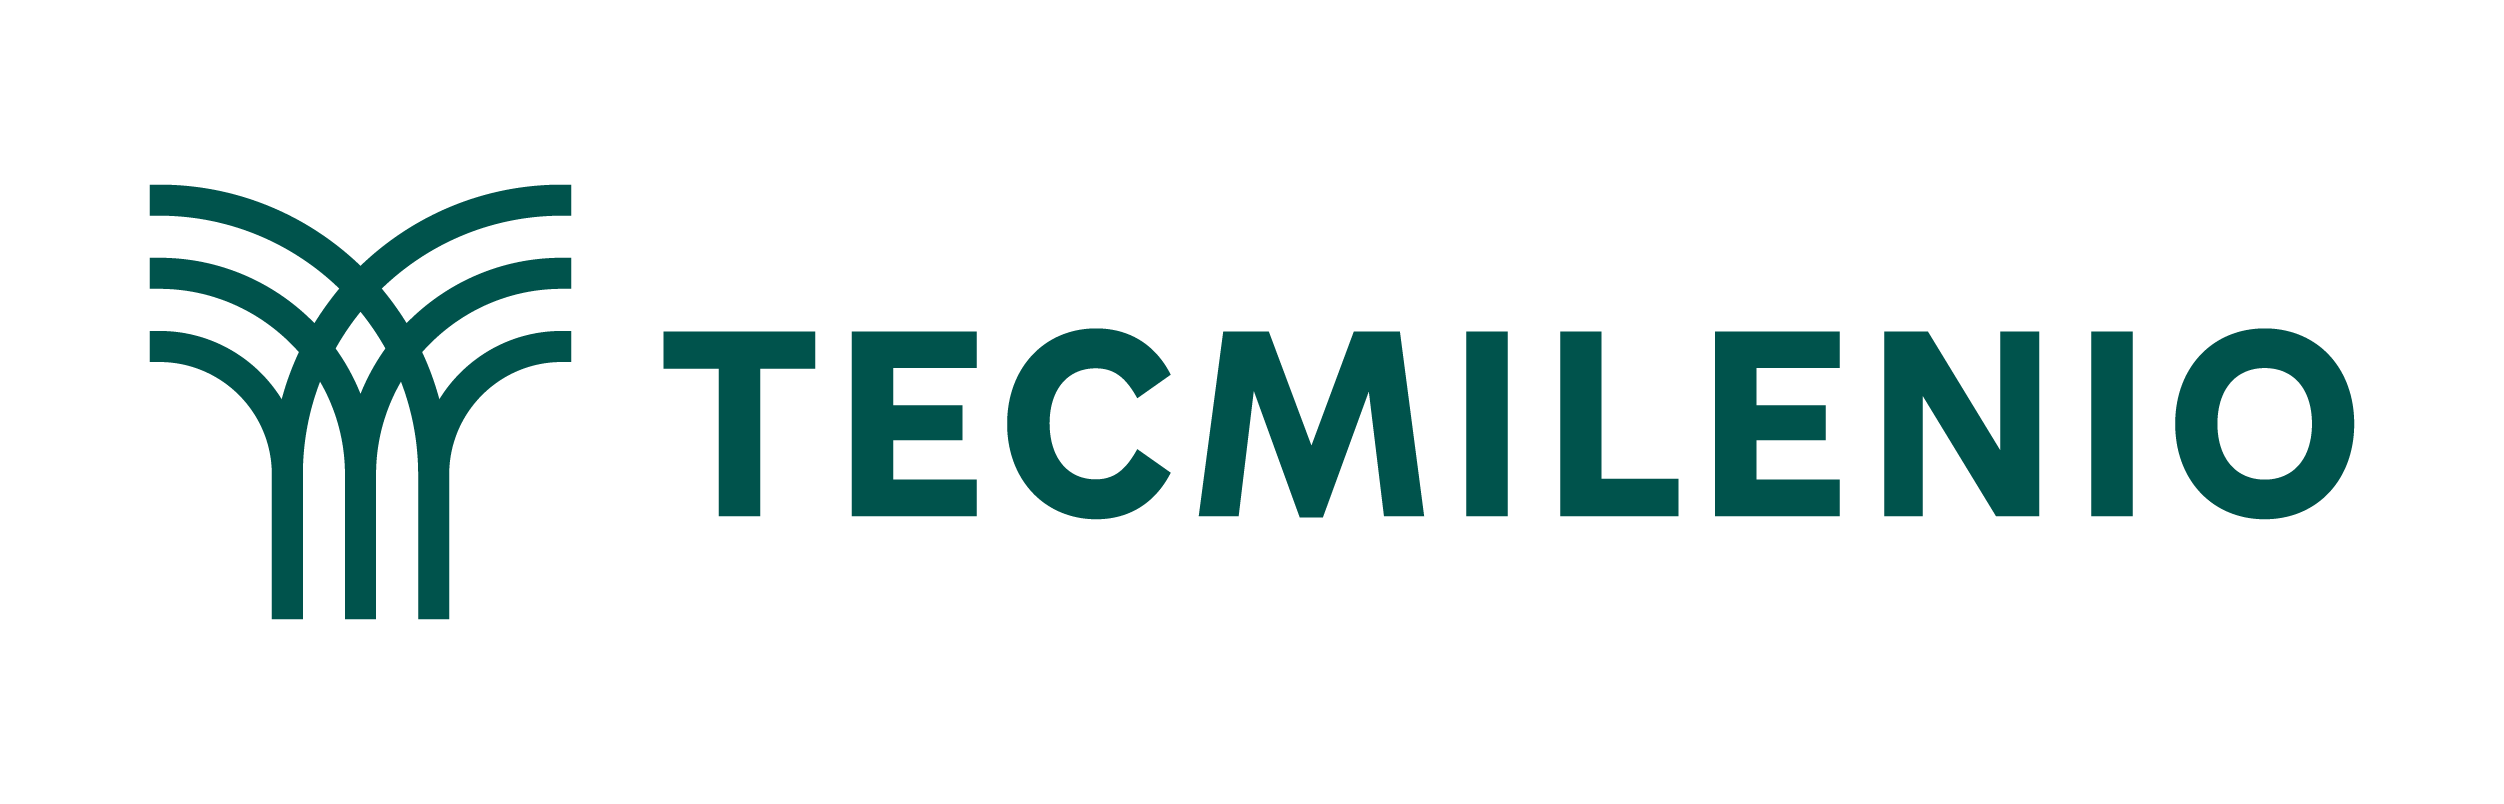












In [162]:

nombre_estudiante = "Claudia Rocio Velandia Velandia"
nombre_profesor = " Luis Ariel Vázquez Piña"
fecha = "8 de marzo de 2026"
print("Fase II del proyecto")
print("Nombre del estudiante:", nombre_estudiante)
print("Nombre del profesor:", nombre_profesor)
print("Fecha:", fecha)

Fase II del proyecto
Nombre del estudiante: Claudia Rocio Velandia Velandia
Nombre del profesor:  Luis Ariel Vázquez Piña
Fecha: 8 de marzo de 2026


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [164]:
#Cargar el dataset (Data)

df = pd.read_csv('datasetetudio.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sesiones               250 non-null    int64  
 1   dia_semana             250 non-null    object 
 2   hora_inicio            250 non-null    int64  
 3   duracion_horas         250 non-null    float64
 4   lugar_estudio          250 non-null    object 
 5   nivel_ruido            250 non-null    int64  
 6   interrupciones         250 non-null    int64  
 7   uso_celular_min        250 non-null    int64  
 8   pausas_realizadas      250 non-null    int64  
 9   tecnica_estudio        250 non-null    object 
 10  energia_inicial        250 non-null    int64  
 11  horas_sueno            250 non-null    float64
 12  calidad_sueno          250 non-null    int64  
 13  nivel_estres           250 non-null    int64  
 14  estado_emocional       250 non-null    object 
 15  tipo_m

In [165]:
import os

if os.path.exists('datasetetudio.csv'):
    print('El archivo datasetetudio.csv se encontró correctamente en el entorno.')
else:
    print('El archivo datasetetudio.csv NO se encontró en el entorno.')

El archivo datasetetudio.csv se encontró correctamente en el entorno.


In [166]:
pd.set_option ('display.max_columns', None)
df.head (5)

,Sesiones,dia_semana,hora_inicio,duracion_horas,lugar_estudio,nivel_ruido,interrupciones,uso_celular_min,pausas_realizadas,tecnica_estudio,energia_inicial,horas_sueno,calidad_sueno,nivel_estres,estado_emocional,tipo_material,dificultad_percibida,cumplimiento_objetivo
0,1,Monday,20,1.7,Casa,5,2,7,0,Pomodoro,5,4.8,3,3,Negativo,Proyecto,3,1
1,2,Monday,9,2.4,Biblioteca,5,1,23,3,Libre,2,4.9,5,1,Negativo,Teoria,4,1
2,1,Tuesday,20,2.2,Casa,5,3,24,0,Practica,3,7.1,2,4,Positivo,Teoria,4,0
3,2,Tuesday,7,2.6,Biblioteca,3,3,54,3,Libre,1,4.2,3,5,Negativo,Teoria,1,0
4,1,Wednesday,18,1.1,Biblioteca,4,0,59,1,Practica,2,5.9,2,5,Positivo,Ejercicios,2,0


In [167]:
df.columns

Index(['Sesiones', 'dia_semana', 'hora_inicio', 'duracion_horas',
       'lugar_estudio', 'nivel_ruido', 'interrupciones', 'uso_celular_min',
       'pausas_realizadas', 'tecnica_estudio', 'energia_inicial',
       'horas_sueno', 'calidad_sueno', 'nivel_estres', 'estado_emocional',
       'tipo_material', 'dificultad_percibida', 'cumplimiento_objetivo'],
      dtype='object')

In [168]:
print(f"El numero de filas es: {df.shape[0]}, El numero de columnas es: {df.shape[1]}")


El numero de filas es: 250, El numero de columnas es: 18


In [169]:
df.describe()

,Sesiones,hora_inicio,duracion_horas,nivel_ruido,interrupciones,uso_celular_min,pausas_realizadas,energia_inicial,horas_sueno,calidad_sueno,nivel_estres,dificultad_percibida,cumplimiento_objetivo
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000
mean,1.500000,15.196000,2.020400,3.044000,2.044000,30.720000,1.424000,3.044000,6.332000,2.884000,3.056000,2.900000,0.38000
std,0.501003,5.207114,0.565352,1.473346,1.377554,18.603925,1.117686,1.478787,1.489864,1.408004,1.390178,1.406382,0.48636
min,1.000000,7.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.00000
25%,1.000000,12.000000,1.600000,2.000000,1.000000,13.250000,0.000000,2.000000,4.900000,2.000000,2.000000,2.000000,0.00000
50%,1.500000,15.000000,2.100000,3.000000,2.000000,29.000000,1.000000,3.000000,6.350000,3.000000,3.000000,3.000000,0.00000
75%,2.000000,20.000000,2.500000,4.000000,3.000000,48.000000,2.000000,4.000000,7.500000,4.000000,4.000000,4.000000,1.00000
max,2.000000,22.000000,3.000000,5.000000,4.000000,60.000000,3.000000,5.000000,9.000000,5.000000,5.000000,5.000000,1.00000


In [170]:
df.describe (include = object)

,dia_semana,lugar_estudio,tecnica_estudio,estado_emocional,tipo_material
count,250,250,250,250,250
unique,7,4,4,3,4
top,Monday,Biblioteca,Practica,Positivo,Proyecto
freq,36,67,65,86,67


In [171]:
df.isnull().sum()

,0
Sesiones,0
dia_semana,0
hora_inicio,0
duracion_horas,0
lugar_estudio,0
nivel_ruido,0
interrupciones,0
uso_celular_min,0
pausas_realizadas,0
tecnica_estudio,0


In [172]:


# Seleccionar las variables en escala 1–5 que influyen en el avance
factores = ["energia_inicial", "calidad_sueno", "nivel_estres", "dificultad_percibida"]

# Calcular el promedio y conviértelo a porcentaje
df["porcentaje_avance"] = (df[factores].mean(axis=1) / 5) * 100

# Definir la variable objetivo según el criterio ≥80%
df["cumplimiento_objetivo_calc"] = (df["porcentaje_avance"] >= 80).astype(int)

# Verificar el resultado de las secciones de estudio
print(df["cumplimiento_objetivo_calc"].value_counts())
print(df["cumplimiento_objetivo_calc"].value_counts(normalize=True) * 100)


cumplimiento_objetivo_calc
0    222
1     28
Name: count, dtype: int64
cumplimiento_objetivo_calc
0    88.8
1    11.2
Name: proportion, dtype: float64


#OBSERVACIONES GENERALES
1. Dimensión del dataset

El conjunto de datos contiene 250 filas y 18 columnas, lo que representa un volumen suficiente para realizar un análisis exploratorio y aplicar modelos de clasificación supervisada.

2. Tipos de datos

Dentro de la información, las columnas se distribuyen en:

float64 (2 columnas): variables continuas como duracion_horas y horas_sueno.

int64 (11 columnas): variables discretas como hora_inicio, nivel_ruido, interrupciones, uso_celular_min, pausas_realizadas, energia_inicial, calidad_sueno, nivel_estres, dificultad_percibida, entre otras.

object (5 columnas): variables categóricas como dia_semana, lugar_estudio, tecnica_estudio, estado_emocional, tipo_material.

3. Columnas incluidas

'Sesiones', 'dia_semana','hora_inicio', 'duracion_horas', 'lugar_estudio', 'nivel_ruido', 'interrupciones', 'uso_celular_min', 'pausas_realizadas', 'tecnica_estudio', 'energia_inicial', 'horas_sueno', 'calidad_sueno', 'nivel_estres', 'estado_emocional', 'tipo_material', 'dificultad_percibida', 'cumplimiento_objetivo'.

4. Calidad de los datos

El dataset no presenta valores faltantes ni nulos, lo que facilita el análisis y evita la necesidad de imputación o limpieza adicional en esta fase.

El dataset está completo, bien estructurado y con tipificación adecuada para análisis exploratorio. La combinación de variables numéricas y categóricas permite estudiar relaciones complejas entre factores ambientales, físicos y emocionales, y su impacto en el cumplimiento de objetivos académicos. Esto confirma que el dataset está listo para la fase de modelado en Machine Learning.



# **ANALISIS DE LA INFORMACION DEL DATASET**


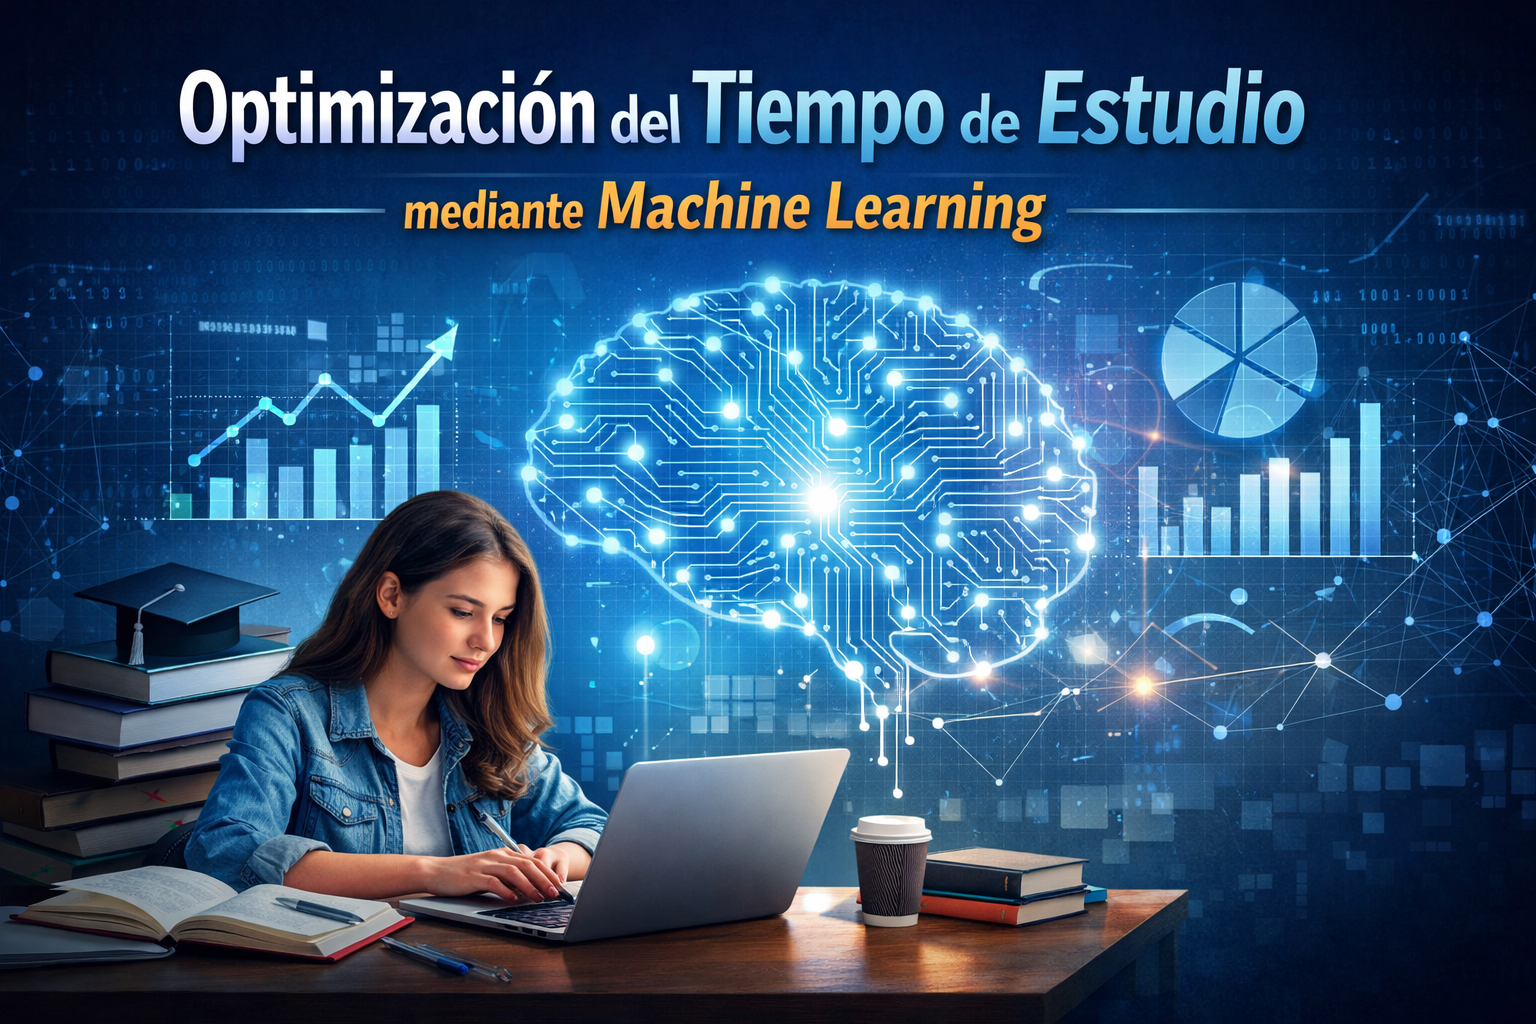

In [173]:
# Conjunto de lugares únicos en el dataset
lugares_estudio = set(df["lugar_estudio"])
print("Lugares únicos:", lugares_estudio)

# Otro conjunto de lugares preferidos
lugares_preferidos = {"Biblioteca", "Casa", "Oficina"}

# Operaciones de conjuntos
print("Intersección (lugares en ambos conjuntos):", lugares_estudio & lugares_preferidos)
print("Unión (todos los lugares):", lugares_estudio | lugares_preferidos)
print("Diferencia (lugares en dataset pero no en preferidos):", lugares_estudio - lugares_preferidos)


Lugares únicos: {'Cafeteria', 'Oficina', 'Biblioteca', 'Casa'}
Intersección (lugares en ambos conjuntos): {'Casa', 'Biblioteca', 'Oficina'}
Unión (todos los lugares): {'Casa', 'Oficina', 'Cafeteria', 'Biblioteca'}
Diferencia (lugares en dataset pero no en preferidos): {'Cafeteria'}


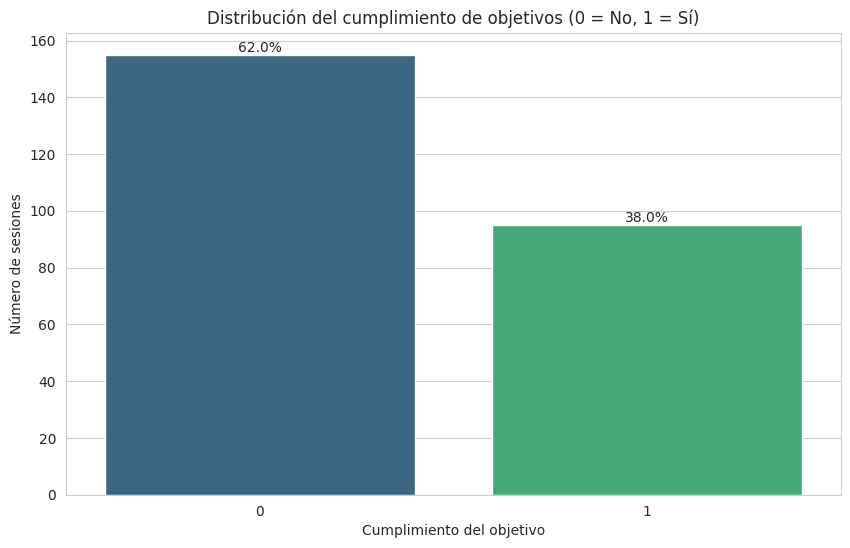

In [174]:

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")


ax = sns.countplot(x="cumplimiento_objetivo", hue="cumplimiento_objetivo", data=df, palette="viridis", legend=False)
plt.title("Distribución del cumplimiento de objetivos (0 = No, 1 = Sí)")
plt.xlabel("Cumplimiento del objetivo")
plt.ylabel("Número de sesiones")

# Añadir porcentajes encima de cada barra
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

# **VARIABLE OBJETIVO**


#1. Distribución de la variable objetivo

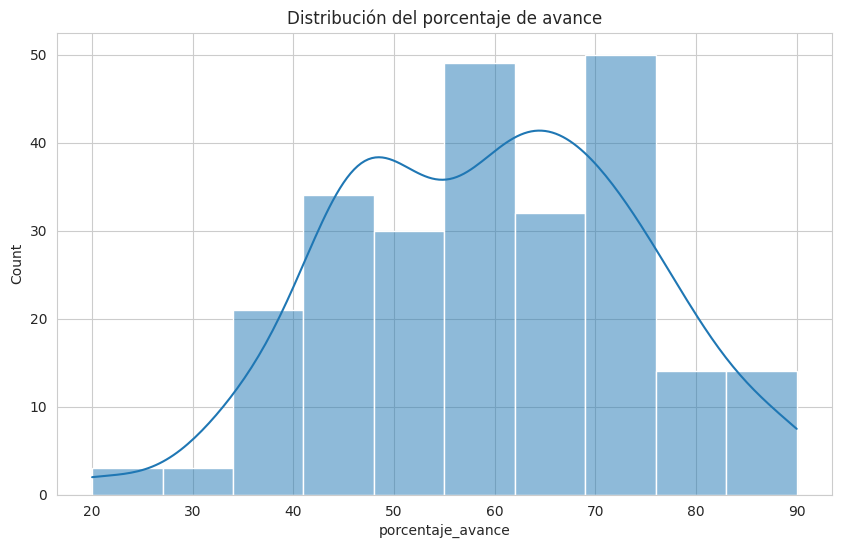

/tmp/ipykernel_507/2972401838.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




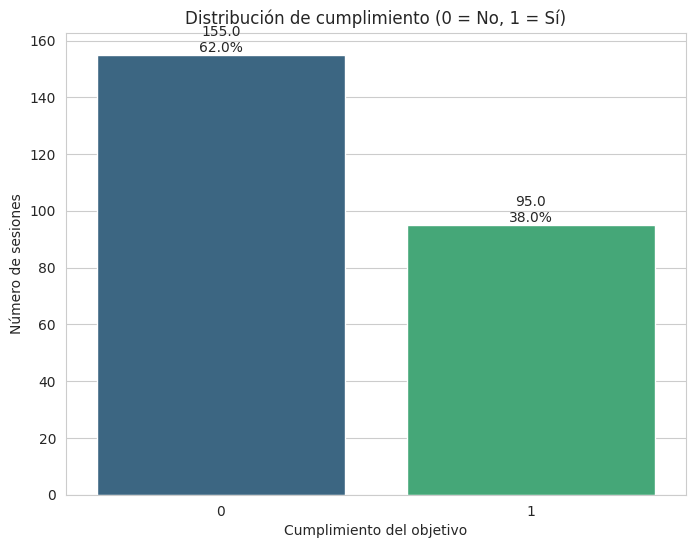

In [175]:

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Histograma del porcentaje de avance
sns.histplot(df["porcentaje_avance"], bins=10, kde=True)
plt.title("Distribución del porcentaje de avance")
plt.show()

# Gráfica de cumplimiento con etiquetas arriba de las barras
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="cumplimiento_objetivo", data=df, palette="viridis")
plt.title("Distribución de cumplimiento (0 = No, 1 = Sí)")
plt.xlabel("Cumplimiento del objetivo")
plt.ylabel("Número de sesiones")

# Añadir etiquetas con conteo y porcentaje
total = len(df)
for p in ax.patches:
    count = p.get_height()
    porcentaje = f'{100 * count/total:.1f}%'
    ax.annotate(f'{count}\n{porcentaje}',
                (p.get_x() + p.get_width()/2., count),
                ha='center', va='bottom')

plt.show()






Estadísticas descriptivas:
 count    250.00000
mean      59.42000
std       14.72518
min       20.00000
25%       50.00000
50%       60.00000
75%       70.00000
max       90.00000
Name: porcentaje_avance, dtype: float64


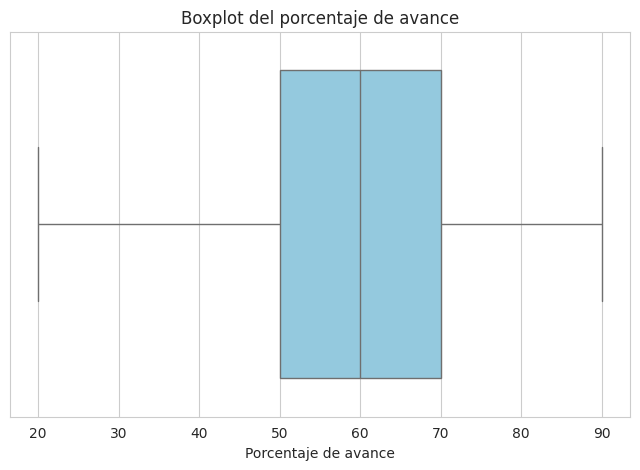

In [176]:


# Estadísticas descriptivas
stats = df['porcentaje_avance'].describe()
print("Estadísticas descriptivas:\n", stats)

# Boxplot para visualizar la dispersión y posibles outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['porcentaje_avance'], color="skyblue")
plt.title("Boxplot del porcentaje de avance")
plt.xlabel("Porcentaje de avance")
plt.show()


La distribución del porcentaje de avance refleja que la mayoría de los proyectos se encuentran en una fase intermedia de desarrollo (50–70%), con pocos casos en etapas iniciales o finales. Esto puede interpretarse como un patrón operativo: los proyectos tienden a avanzar hasta cierto punto y luego se ralentizan antes de completarse.

Este hallazgo es útil para justificar la variable objetivo, ya que muestra dónde se concentra el desempeño y dónde podrían existir barreras para alcanzar la finalización total.

/tmp/ipykernel_507/3428767964.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




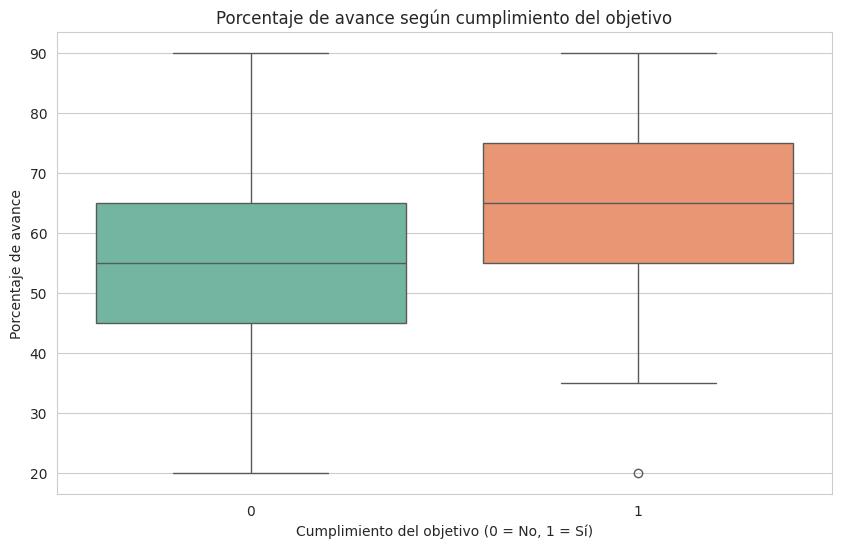

In [177]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Gráfico de distribución de porcentajes según cumplimiento
sns.boxplot(x="cumplimiento_objetivo", y="porcentaje_avance", data=df, palette="Set2")
plt.title("Porcentaje de avance según cumplimiento del objetivo")
plt.xlabel("Cumplimiento del objetivo (0 = No, 1 = Sí)")
plt.ylabel("Porcentaje de avance")
plt.show()


#2. Relación entre energía inicial y cumplimiento


/tmp/ipykernel_507/537545284.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




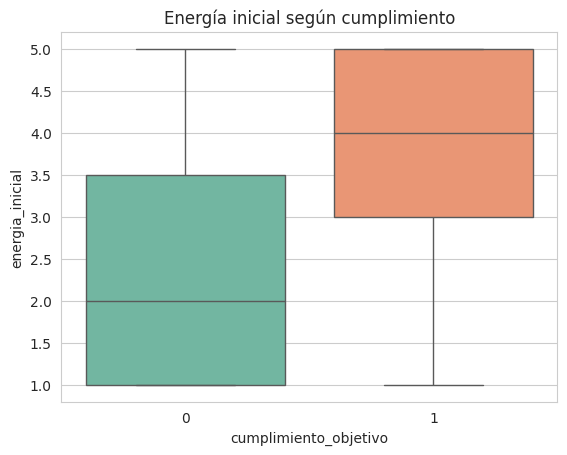

In [178]:
sns.boxplot(x="cumplimiento_objetivo", y="energia_inicial", data=df, palette="Set2")
plt.title("Energía inicial según cumplimiento")
plt.show()


#3. Horas de sueño vs cumplimiento


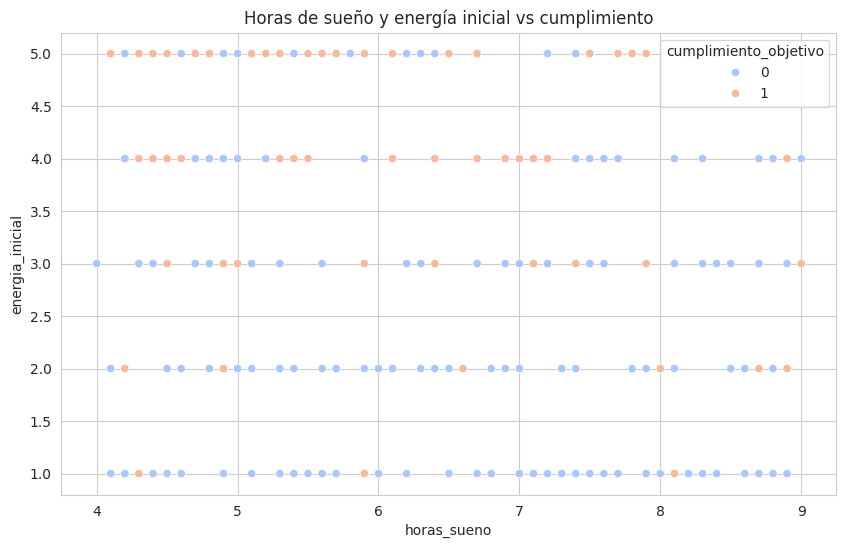

In [179]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="horas_sueno", y="energia_inicial", hue="cumplimiento_objetivo", data=df, palette="coolwarm")
plt.title("Horas de sueño y energía inicial vs cumplimiento")
plt.show()


#4. Variables categóricas

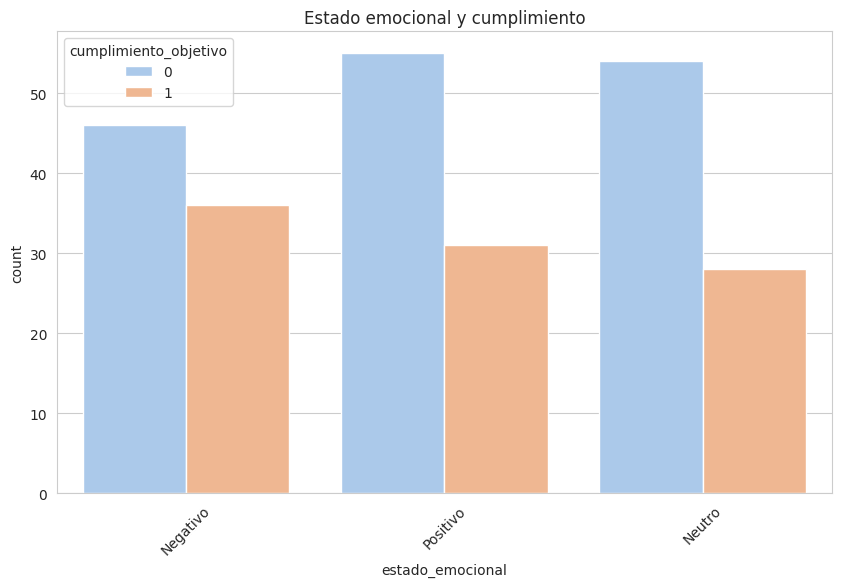

In [180]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(x="estado_emocional", hue="cumplimiento_objetivo", data=df, palette="pastel")
plt.title("Estado emocional y cumplimiento")
plt.xticks(rotation=45)
plt.show()


#5. Nivel de ruido vs cumplimiento

/tmp/ipykernel_507/1084504117.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




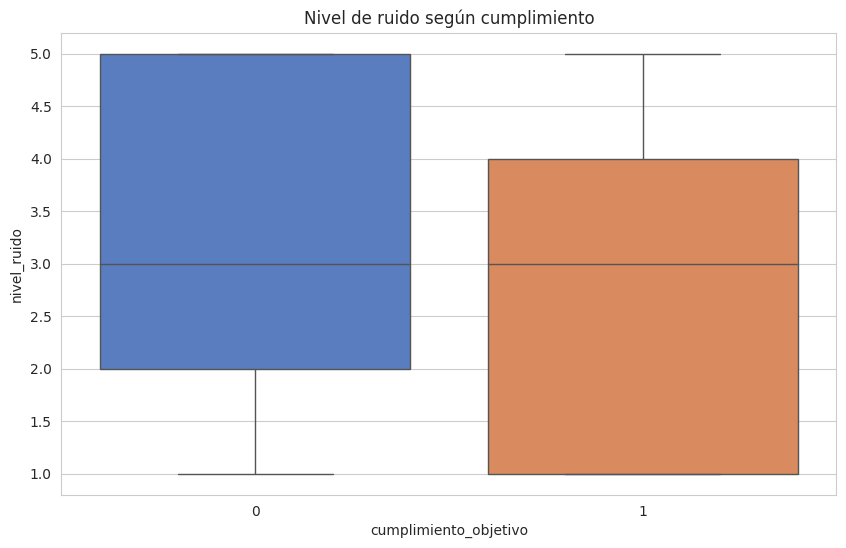

In [181]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.boxplot(x="cumplimiento_objetivo", y="nivel_ruido", data=df, palette="muted")
plt.title("Nivel de ruido según cumplimiento")
plt.show()


#6. Correlación entre variables numéricas





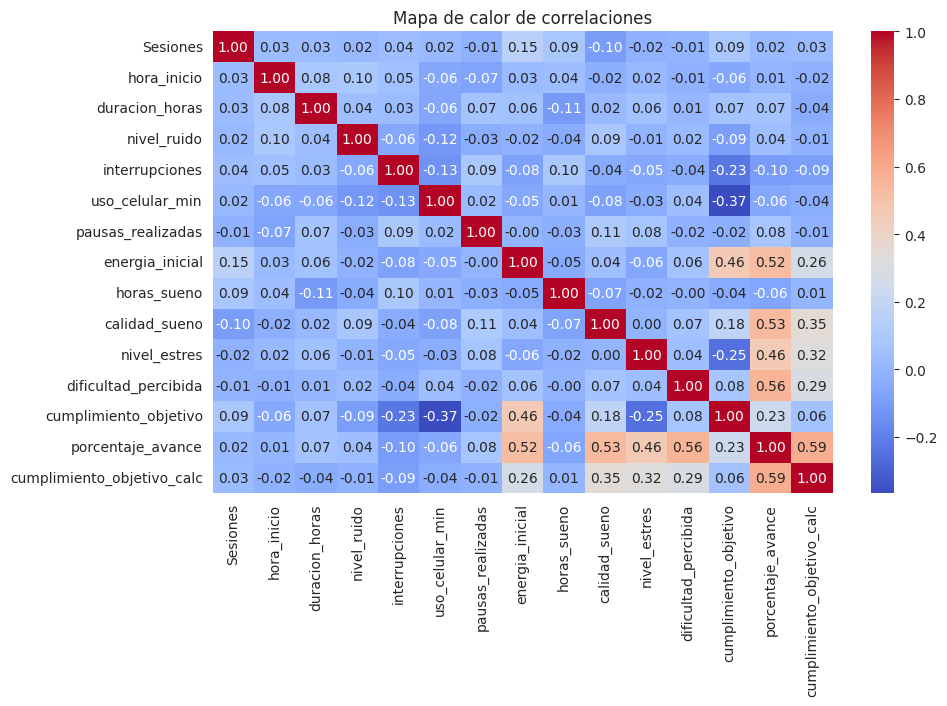

In [182]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()


# ANALISIS COMPLEMENTARIOS

Text(0.5, 1.0, 'Cumplimiento por técnica de estudio')

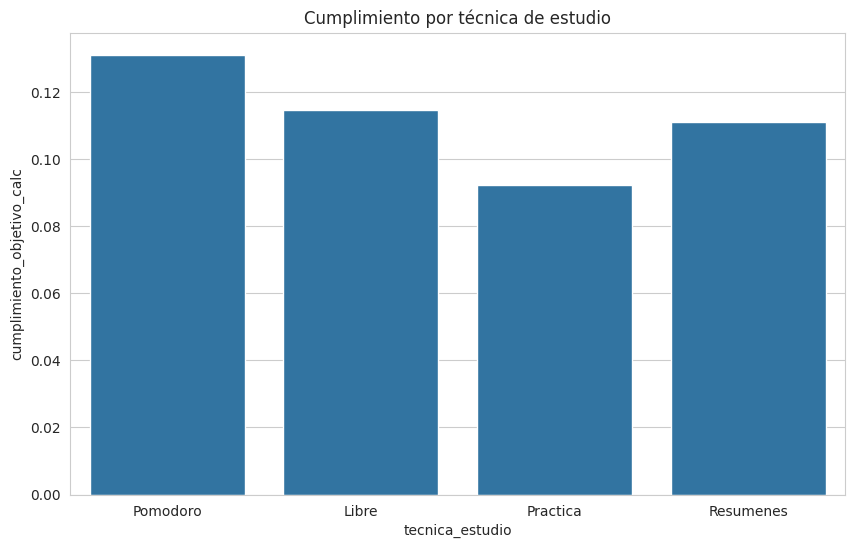

In [183]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x="tecnica_estudio", y="cumplimiento_objetivo_calc", data=df, errorbar=None)
plt.title("Cumplimiento por técnica de estudio")

#2. Cumplimiento por lugar de estudio


/tmp/ipykernel_507/3486889057.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




Text(0.5, 1.0, 'Cumplimiento por lugar de estudio')

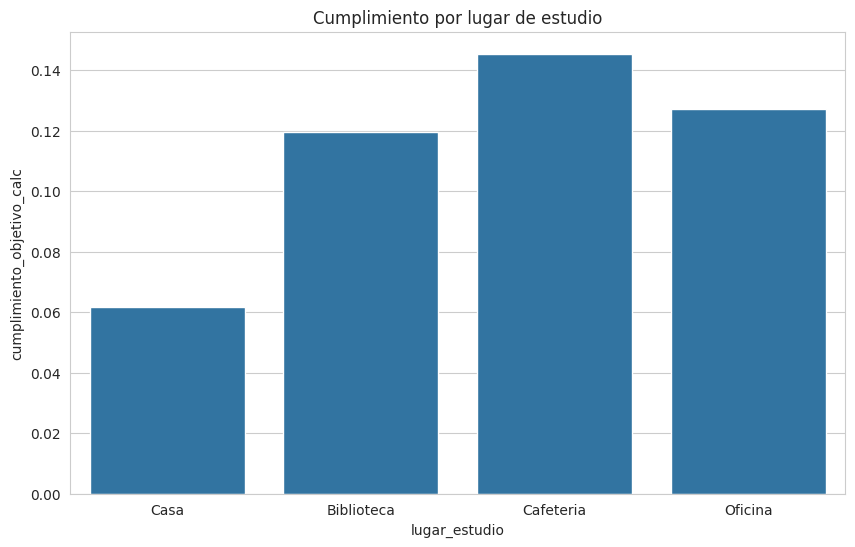

In [184]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x="lugar_estudio", y="cumplimiento_objetivo_calc", data=df, ci=None)
plt.title("Cumplimiento por lugar de estudio")

#3. Distribución cruzada de dos variables categóricas

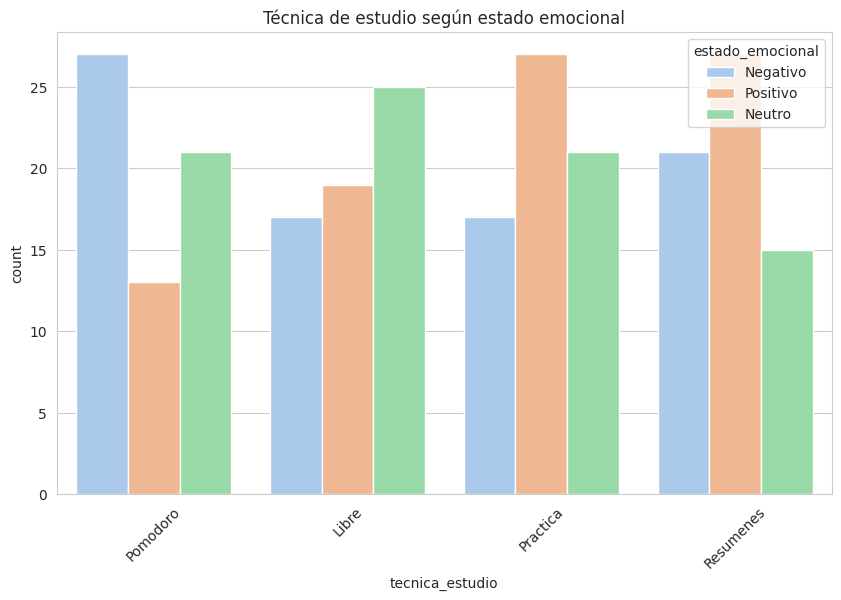

In [185]:
plt.figure(figsize=(10,6))
sns.countplot(x="tecnica_estudio", hue="estado_emocional", data=df, palette="pastel")
plt.title("Técnica de estudio según estado emocional")
plt.xticks(rotation=45)
plt.show()


# 4.Relación entre interrupciones y cumplimiento

/tmp/ipykernel_507/3949343764.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




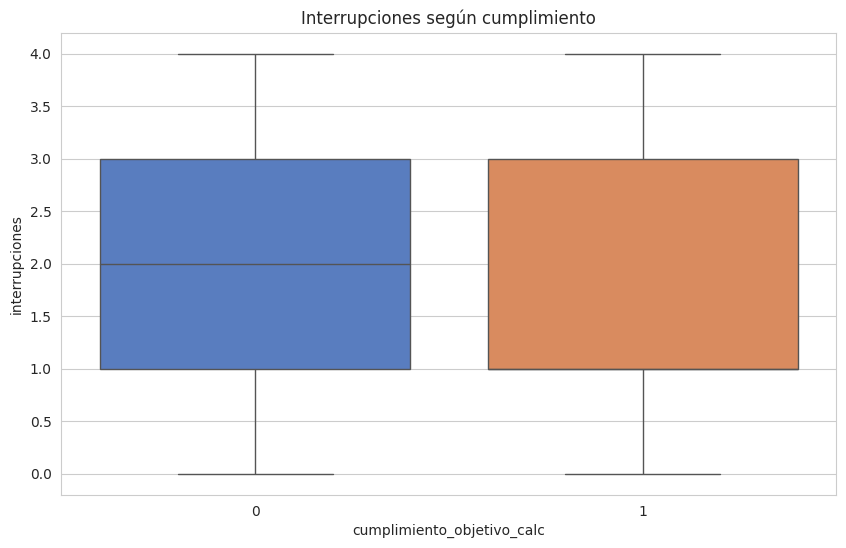

In [186]:
plt.figure(figsize=(10,6))
sns.boxplot(x="cumplimiento_objetivo_calc", y="interrupciones", data=df, palette="muted")
plt.title("Interrupciones según cumplimiento")
plt.show()


# 5. Duración de la sesión vs cumplimiento  

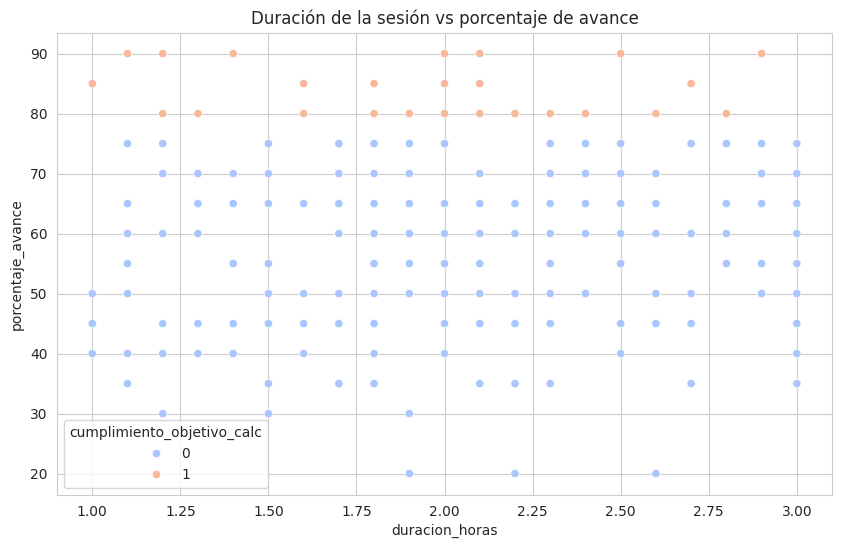

In [187]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="duracion_horas", y="porcentaje_avance", hue="cumplimiento_objetivo_calc", data=df, palette="coolwarm")
plt.title("Duración de la sesión vs porcentaje de avance")
plt.show()


# 6. Treemap cumplimiento por tecnica y lugar de estudio

In [188]:
# Diccionario: técnicas de estudio
tecnicas_dict = {
    "Pomodoro": "Técnica basada en intervalos de tiempo",
    "Resumenes": "Síntesis de la información clave",
    "Practica": "Resolución de ejercicios prácticos",
    "Libre": "Estudio sin estructura definida"
}

# Conjunto: lugares únicos de estudio en el dataset
lugares_unicos = set(df["lugar_estudio"])
print("Diccionario de técnicas:", tecnicas_dict)
print("Conjunto de lugares únicos:", lugares_unicos)

# Carcular el porcentaje de cumplimiento en un DataFrame
def calcular_cumplimiento(dataframe):
    total = len(dataframe)
    cumplidas = dataframe["cumplimiento_objetivo_calc"].sum()
    porcentaje = (cumplidas / total) * 100
    return f"Cumplimiento: {cumplidas}/{total} sesiones ({porcentaje:.1f}%)"

# Uso de la función dataset
resultado = calcular_cumplimiento(df)
print(resultado)


Diccionario de técnicas: {'Pomodoro': 'Técnica basada en intervalos de tiempo', 'Resumenes': 'Síntesis de la información clave', 'Practica': 'Resolución de ejercicios prácticos', 'Libre': 'Estudio sin estructura definida'}
Conjunto de lugares únicos: {'Cafeteria', 'Oficina', 'Biblioteca', 'Casa'}
Cumplimiento: 28/250 sesiones (11.2%)


In [189]:


# Agrupar por técnica y cumplimiento
df_treemap = (
    df.groupby(["tecnica_estudio", "cumplimiento_objetivo_calc"])
    .size()
    .reset_index(name="count")
)

print(df_treemap.head())



  tecnica_estudio  cumplimiento_objetivo_calc  count
0           Libre                           0     54
1           Libre                           1      7
2        Pomodoro                           0     53
3        Pomodoro                           1      8
4        Practica                           0     59


In [190]:
plt.figure(figsize=(10,6))

fig = px.treemap(
    df,
    path=["tecnica_estudio", "lugar_estudio", "cumplimiento_objetivo_calc"],
    values="duracion_horas",
    color="cumplimiento_objetivo_calc",
    color_continuous_scale=["#FF6B6B", "#4CAF50"],
    title="Treemap de cumplimiento por técnica y lugar de estudio"
)
fig.show()


<Figure size 1000x600 with 0 Axes>

# 7. "Proporción de cumplimiento de objetivos en el dataset"

In [191]:


# función
def calcular_cumplimiento(dataframe):
    total = len(dataframe)
    cumplidas = dataframe["cumplimiento_objetivo"].sum()
    no_cumplidas = total - cumplidas
    return cumplidas, no_cumplidas, total

# obtener valores
cumplidas, no_cumplidas, total = calcular_cumplimiento(df)

# dataframe para gráfica
df_cumplimiento = pd.DataFrame({
    "Estado": ["Cumplidas", "No cumplidas"],
    "Sesiones": [cumplidas, no_cumplidas]})

# gráfica
fig = px.bar(
    df_cumplimiento,
    x="Estado",
    y="Sesiones",
    color="Estado",
    text="Sesiones",
    title=f"Distribución del cumplimiento de objetivos ({cumplidas}/{total} sesiones cumplidas)"
)

fig.show()

# **CONCLUSIONES**

A partir del análisis de los datos recopilados sobre los hábitos de estudio y los factores que influyen en el cumplimiento de objetivos académicos de un estudiante en particular, fue posible identificar patrones relevantes que permiten comprender mejor cómo se optimiza el tiempo durante sus sesiones de estudio.

En primer lugar, el análisis de la distribución del cumplimiento de objetivos permitió observar la proporción de sesiones en las que el estudiante logró alcanzar las metas propuestas. Los resultados indican que una parte importante de las sesiones resultaron productivas, aunque existen factores externos y personales que influyen en su desempeño.

El análisis de la variable binaria de cumplimiento de objetivos (0 = No, 1 = Sí) mostró que el estudiante alcanzó sus metas en el 38% de las sesiones, mientras que en el 62% restante no logró cumplirlas. Este resultado refleja una tendencia en la que el progreso parcial no siempre se traduce en finalización exitosa, lo que coincide con la concentración observada en los rangos intermedios de avance (50–70%). En términos operativos, el 0 y el 1 representan los extremos del proceso: el fracaso en el cumplimiento y la consecución total de la meta. La predominancia del “0” evidencia la necesidad de implementar estrategias que reduzcan las barreras y aumenten la probabilidad de alcanzar el “1”, fortaleciendo así la eficiencia en el uso del tiempo y el rendimiento académico.

En relación con la energía inicial, los resultados muestran que un mayor nivel de energía al iniciar una sesión de estudio tiende a asociarse con una mayor probabilidad de cumplir los objetivos establecidos. Esto sugiere que el estado físico y mental previo al estudio influye significativamente en la productividad académica de este caso.

Por otra parte, el análisis de las horas de sueño evidenció que cuando el estudiante descansa adecuadamente presenta una tendencia mayor a completar sus metas de estudio. Este hallazgo resalta la importancia de mantener hábitos de descanso saludables para mejorar el rendimiento académico y la concentración durante las sesiones de aprendizaje.

Asimismo, el estudio del nivel de ruido en el entorno de estudio mostró que ambientes con mayores niveles de ruido afectan negativamente la concentración, reduciendo la probabilidad de cumplir con los objetivos establecidos. Esto confirma la relevancia de contar con espacios adecuados y tranquilos para favorecer el aprendizaje.

En cuanto al número de interrupciones, se observó que un incremento en las distracciones durante la sesión de estudio se relaciona con un menor nivel de cumplimiento de objetivos. Este resultado demuestra que la gestión de distracciones es un factor clave para mejorar la eficiencia en el uso del tiempo.

El análisis del lugar de estudio y las técnicas de aprendizaje utilizadas también permitió identificar que ciertos ambientes y métodos de estudio favorecen un mayor nivel de productividad. La elección de un espacio adecuado y el uso de técnicas de estudio efectivas contribuyen a optimizar el tiempo dedicado al aprendizaje.

De manera complementaria, el análisis de la variable porcentaje de avance mostró que la mayoría de las sesiones se concentran en un rango intermedio de desarrollo, específicamente entre el 50% y el 70%. La media (59.4) y la mediana (60) reflejan una distribución simétrica, mientras que el rango intercuartílico confirma que gran parte de los avances se estabilizan en esa fase. Además, los valores extremos —mínimo de 20% y máximo de 90%— evidencian que existen pocas sesiones en etapas iniciales o totalmente concluidas. Este hallazgo sugiere que el estudiante tiende a avanzar hasta cierto punto y posteriormente enfrenta barreras que dificultan la finalización total, lo cual constituye un área de oportunidad para implementar estrategias que impulsen el cierre exitoso de las actividades.

Finalmente, el uso de herramientas de análisis de datos en Python, mediante las librerías NumPy, Pandas y Matplotlib, permitió organizar, procesar y visualizar la información de forma clara y eficiente. Estas herramientas resultan fundamentales en el ámbito de la inteligencia artificial y el análisis de datos, ya que facilitan la identificación de patrones y la toma de decisiones basadas en evidencia.

En conclusión, el presente análisis demuestra que factores como el descanso, el nivel de energía, el entorno de estudio, la gestión de distracciones y la concentración del avance en fases intermedias influyen de manera significativa en el cumplimiento de objetivos académicos de este estudiante. Comprender estos factores permite desarrollar estrategias más efectivas para optimizar el tiempo de estudio y mejorar su rendimiento académico.



